> ℹ️ **이 노트북은 진단(4사분면) 보조입니다. 최종 주 모델은 nb24(단일 통합 모델 + 검증)** 이고, 본 노트북은 그 결과를 매출×생존 사분면으로 *설명*합니다.

# 22. 최종 창업 입지평가 (정직본 종합)

본 프로젝트의 최종 산출물. 두 개의 **검증된·정직한** 축을 결합해 입지를 평가한다.

| 축 | 출처 | 정직성 |
|---|---|---|
| **매출 잠재력** | 우리 HGB 모델(**누설 5개 제거**, 점포당 매출) | holdout R²≈0.64 (누설본 0.87은 폐기) |
| **생존** | **평균 영업기간**(OPR_SALE_MT_AVRG, 측정 지수) | 점포 평균 영업개월. 신뢰도 r=0.94(추정오차 없음) |

> 두 축 모두 **우리 데이터(서울시 상권)** 로 만든 자체 파이프라인. 창업기상도 API는 검증 전용.
> 두 축은 약한 상관이라 결합 시 독립 정보가 더해진다.
> 최종 입지점수 = 0.5·매출백분위 + 0.5·지속가능성백분위 (업종·분기 내 자치구 백분위; 가중치는 값 선택, §21.8 민감도로 정당화).

## 데이터
- 정직 모델 예측: `honest_predictions.csv` (누설 제거)
- 창업기상도: `sbiz_weather_gu.csv` (2025 Q3·Q4 × 19업종 × 25자치구, API 캐시)
- 통합점수: `integrated_location_score.csv` (§21, 매출×자체생존, 50업종×24분기)
- **생존 파생변수 파이프라인**: `sbiz_weather_features.csv` (sustainability·z_survival·pct_survival 등) + `validate_survival_proper.py`

In [1]:
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib, matplotlib.pyplot as plt, platform
matplotlib.rcParams['font.family'] = 'AppleGothic' if platform.system()=='Darwin' else 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
PROC = Path('/Users/ijunsu/Documents/Documents/capston/data_analysis/trade_area_project/data/processed')

m  = pd.read_csv(PROC/'integrated_location_score.csv')   # gu,biz,q_int,sales_pct,durability_pct,integrated_score,quadrant + 원점수
sb = pd.read_csv(PROC/'sbiz_weather_gu.csv')             # 창업기상 원점수(생존·전망 등)
print('통합점수:', m.shape, '| 업종', m.biz.nunique(), '자치구', m.gu.nunique(), '분기', sorted(m.q_int.unique()))
m.head()

통합점수: (17568, 9) | 업종 50 자치구 25 분기 [np.int64(20201), np.int64(20202), np.int64(20203), np.int64(20204), np.int64(20211), np.int64(20212), np.int64(20213), np.int64(20214), np.int64(20221), np.int64(20222), np.int64(20223), np.int64(20224), np.int64(20231), np.int64(20232), np.int64(20233), np.int64(20234), np.int64(20241), np.int64(20242), np.int64(20243), np.int64(20244), np.int64(20251), np.int64(20252), np.int64(20253), np.int64(20254)]


,gu,biz,q_int,p_high_90,durability_raw,sales_pct,durability_pct,integrated_score,quadrant
0,강남구,PC방,20201,0.348066,87.718447,100.0,10.0,55.0,②고위험고수익(고매출·저생존)
1,강남구,PC방,20202,0.218537,88.815534,77.8,11.1,44.4,②고위험고수익(고매출·저생존)
2,강남구,PC방,20203,0.028352,88.679612,36.4,9.1,22.7,④회피(저매출·저생존)
3,강남구,PC방,20204,0.520525,89.388350,100.0,16.7,58.3,②고위험고수익(고매출·저생존)
4,강남구,PC방,20211,0.213970,90.747573,90.9,9.1,50.0,②고위험고수익(고매출·저생존)


## §22.1 최종 입지점수 분포 — 4사분면

①최적(고매출·고생존) / ②고위험·고수익(고매출·저생존) / ③안정·저성장(저매출·고생존) / ④회피(저매출·저생존)

사분면 분포(2025 Q4):
quadrant
①최적(고매출·고생존)        213
②고위험고수익(고매출·저생존)    190
③안정저성장(저매출·고생존)     190
④회피(저매출·저생존)        140


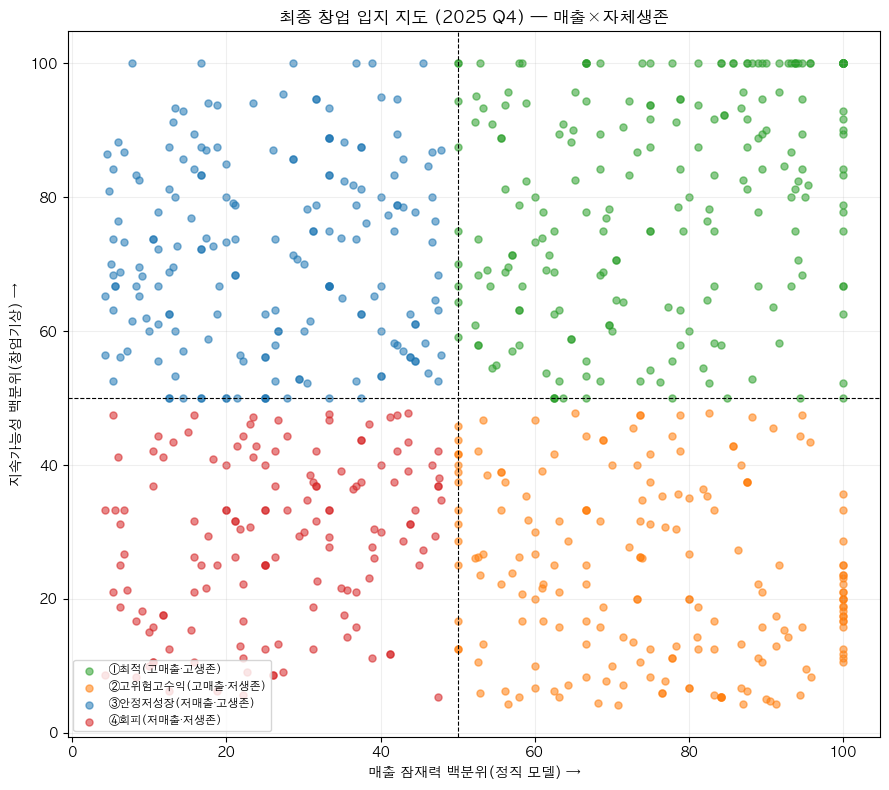

In [2]:
latest = m[m.q_int==m.q_int.max()].copy()   # 최신 분기(2025 Q4)
print('사분면 분포(2025 Q4):'); print(latest['quadrant'].value_counts().to_string())

colors={'①최적(고매출·고생존)':'#2ca02c','②고위험고수익(고매출·저생존)':'#ff7f0e',
        '③안정저성장(저매출·고생존)':'#1f77b4','④회피(저매출·저생존)':'#d62728'}
fig,ax=plt.subplots(figsize=(9,8))
for q,c in colors.items():
    s=latest[latest.quadrant==q]; ax.scatter(s.sales_pct,s.durability_pct,s=26,alpha=.55,color=c,label=q)
ax.axvline(50,color='k',lw=.8,ls='--'); ax.axhline(50,color='k',lw=.8,ls='--')
ax.set_xlabel('매출 잠재력 백분위(정직 모델) →'); ax.set_ylabel('지속가능성 백분위(창업기상) →')
ax.set_title('최종 창업 입지 지도 (2025 Q4) — 매출×자체생존')
ax.legend(loc='lower left',fontsize=8); ax.grid(alpha=.2); plt.tight_layout(); plt.show()

## §22.2 업종별 TOP3 추천 입지 (①최적 우선, 통합점수 순)

각 업종에서 '매출도 높고 생존도 좋은' 자치구를 우선 추천한다.

In [3]:
rows=[]
for biz,g in latest.groupby('biz'):
    top=g.sort_values('integrated_score',ascending=False).head(3)
    for rank,(_,r) in enumerate(top.iterrows(),1):
        rows.append({'업종':biz,'순위':rank,'자치구':r['gu'],
                     '매출백분위':round(r['sales_pct']),'지속백분위':round(r['durability_pct']),
                     '통합점수':round(r['integrated_score']),'사분면':r['quadrant'][:4]})
rec=pd.DataFrame(rows)
print('=== 업종별 추천 입지 TOP3 (2025 Q4) ===')
print(rec.to_string(index=False))

=== 업종별 추천 입지 TOP3 (2025 Q4) ===
        업종  순위  자치구  매출백분위  지속백분위  통합점수  사분면
       PC방   1  송파구    100     67    83 ①최적(
       PC방   2 서대문구     50    100    75 ①최적(
       PC방   3  강남구     83     33    58 ②고위험
        가구   1   중구     88    100    94 ①최적(
        가구   2  서초구     62     75    69 ①최적(
        가구   3  강남구    100     12    56 ②고위험
      가전제품   1 영등포구    100     67    83 ①최적(
      가전제품   2  종로구     67    100    83 ①최적(
      가전제품   3  강남구     33     33    33 ④회피(
       노래방   1   중구     89    100    94 ①최적(
       노래방   2  서초구     72     83    78 ①최적(
       노래방   3 영등포구     50     94    72 ①최적(
        문구   1  서초구    100     92    96 ①최적(
        문구   2   중구     67    100    83 ①최적(
        문구   3  송파구     83     58    71 ①최적(
      미곡판매   1   중구    100    100   100 ①최적(
      미곡판매   2  구로구     60     80    70 ①최적(
      미곡판매   3  강서구     80     20    50 ②고위험
       미용실   1  서초구     96     82    89 ①최적(
       미용실   2  종로구     46    100    73 ③안정저
       미용실   3 동대문구   

## §22.3 ②고위험·고수익 경고 리스트

매출 잠재력은 상위지만 생존·전망이 하위인 입지 — 단일 매출 모델이면 추천했을 '함정'.

In [4]:
warn=latest[latest.quadrant.str.startswith('②')].sort_values('sales_pct',ascending=False)
print(f'②고위험·고수익: {len(warn)}건 (2025 Q4)')
print(warn[['gu','biz','sales_pct','durability_pct','integrated_score']].head(12).to_string(index=False))

②고위험·고수익: 190건 (2025 Q4)
 gu     biz  sales_pct  durability_pct  integrated_score
강남구   치킨전문점      100.0            23.5              61.8
강남구    예술학원      100.0            21.1              60.5
송파구     청과상      100.0            35.7              67.9
강남구      가구      100.0            12.5              56.2
강남구      화초      100.0            20.0              60.0
강남구 호프-간이주점      100.0            19.0              59.5
강남구     한의원      100.0            11.8              55.9
강남구   한식음식점      100.0            21.1              60.5
강남구     편의점      100.0            20.0              60.0
강남구   커피-음료      100.0            17.4              58.7
강서구      서적      100.0            16.7              58.3
강남구    치과의원      100.0            20.0              60.0


## §22.4 최종 평가 함수 — (자치구, 업종) → 입지 진단

매출 잠재력·생존·전망을 묶어 사람이 읽는 권고문을 생성한다.

In [5]:
api_q = sb[sb.q_int==sb.q_int.max()]   # 창업기상도 = 검증참고용
def evaluate(gu, biz):
    r = latest[(latest.gu==gu)&(latest.biz==biz)]
    if len(r)==0: return f'{gu} {biz}: 데이터 없음'
    r=r.iloc[0]; quad=r['quadrant']
    msg={'①':'추천 — 매출·생존 모두 양호','②':'주의 — 매출 높으나 생존 약함(포화 위험)',
         '③':'보수적 — 안정적이나 매출 낮음','④':'비추천 — 매출·생존 모두 하위'}[quad[0]]
    a = api_q[(api_q.gu==gu)&(api_q.biz==biz)]
    apis = (f"  · (검증참고) 창업기상 생존 {a.iloc[0]['sb_survival_score']:.0f}/전망 {a.iloc[0]['sb_prospect_score']:.0f}"
            if len(a) else "  · (창업기상 API: 해당 업종 미수집)")
    return (f"[{gu} · {biz}]  통합 입지점수 {r['integrated_score']:.0f}/100  → {quad}\n"
            f"  · 매출 잠재력 백분위 {r['sales_pct']:.0f}  · 생존 백분위 {r['durability_pct']:.0f} (영업기간)\n"
            f"  · 평균 영업기간 {r['durability_raw']:.0f}개월\n{apis}\n  · 권고: {msg}")

for gu,biz in [('강남구','문구'),('중구','핸드폰'),('동작구','미용실'),('성동구','의약품'),('강남구','커피-음료')]:
    print(evaluate(gu,biz)); print()

[강남구 · 문구]  통합 입지점수 58/100  → ②고위험고수익(고매출·저생존)
  · 매출 잠재력 백분위 92  · 생존 백분위 25 (영업기간)
  · 평균 영업기간 112개월
  · (검증참고) 창업기상 생존 36/전망 44
  · 권고: 주의 — 매출 높으나 생존 약함(포화 위험)

[중구 · 핸드폰]  통합 입지점수 100/100  → ①최적(고매출·고생존)
  · 매출 잠재력 백분위 100  · 생존 백분위 100 (영업기간)
  · 평균 영업기간 139개월
  · (창업기상 API: 해당 업종 미수집)
  · 권고: 추천 — 매출·생존 모두 양호

[동작구 · 미용실]  통합 입지점수 43/100  → ③안정저성장(저매출·고생존)
  · 매출 잠재력 백분위 14  · 생존 백분위 73 (영업기간)
  · 평균 영업기간 123개월
  · (검증참고) 창업기상 생존 55/전망 76
  · 권고: 보수적 — 안정적이나 매출 낮음

[성동구 · 의약품]  통합 입지점수 50/100  → ②고위험고수익(고매출·저생존)
  · 매출 잠재력 백분위 68  · 생존 백분위 32 (영업기간)
  · 평균 영업기간 116개월
  · (검증참고) 창업기상 생존 35/전망 56
  · 권고: 주의 — 매출 높으나 생존 약함(포화 위험)

[강남구 · 커피-음료]  통합 입지점수 59/100  → ②고위험고수익(고매출·저생존)
  · 매출 잠재력 백분위 100  · 생존 백분위 17 (영업기간)
  · 평균 영업기간 112개월
  · (검증참고) 창업기상 생존 40/전망 37
  · 권고: 주의 — 매출 높으나 생존 약함(포화 위험)



## §22.5 자치구 종합 — 어디가 창업하기 좋은가 (전 업종 평균)

=== 자치구별 평균 입지점수 (2025 Q4, 수집 업종 평균) ===
        매출     지속    통합
gu                     
중구    81.7  100.0  90.8
종로구   68.5   95.4  82.0
영등포구  65.1   92.0  78.6
서초구   76.5   80.7  78.6
동대문구  46.4   87.5  66.9
구로구   47.5   75.3  61.4
양천구   58.0   63.1  60.5
송파구   70.9   46.3  58.6
서대문구  29.1   84.7  56.9
동작구   37.7   71.8  54.8
강남구   87.1   21.0  54.0
용산구   53.8   52.3  53.1
은평구   44.6   57.5  51.1
금천구   27.9   69.9  48.9
관악구   49.3   47.7  48.5
성북구   30.2   64.7  47.4
강동구   52.2   33.2  42.7
강북구   30.4   54.5  42.5
성동구   43.5   36.3  39.9
도봉구   37.2   41.1  39.1
마포구   67.5    7.0  37.2
광진구   43.7   29.2  36.5
강서구   53.4   14.5  33.9
중랑구   32.2   26.0  29.1
노원구   43.5   10.4  27.0


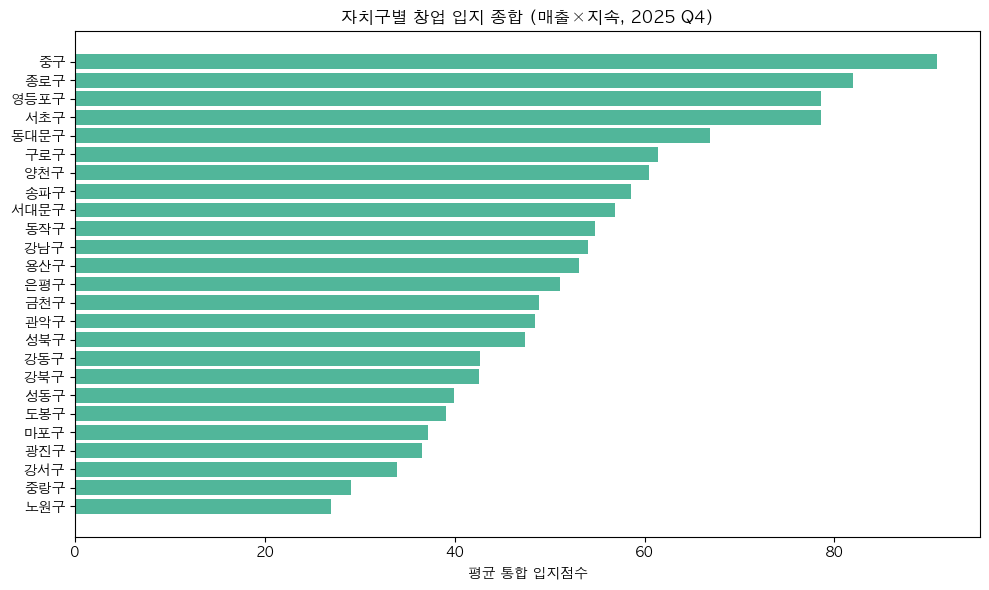

In [6]:
gu_rank = latest.groupby('gu').agg(매출=('sales_pct','mean'),지속=('durability_pct','mean'),
                                   통합=('integrated_score','mean')).round(1).sort_values('통합',ascending=False)
print('=== 자치구별 평균 입지점수 (2025 Q4, 수집 업종 평균) ==='); print(gu_rank.to_string())

fig,ax=plt.subplots(figsize=(10,6))
g=gu_rank.sort_values('통합')
ax.barh(g.index,g['통합'],color='#3a8',alpha=.85)
ax.set_xlabel('평균 통합 입지점수'); ax.set_title('자치구별 창업 입지 종합 (매출×지속, 2025 Q4)')
plt.tight_layout(); plt.show()

## §22.6 최종 결론 — 정직한 창업 입지평가

**산출물**: (자치구 × 업종) 단위 통합 입지점수 + 4사분면 권고 + 평가 함수.

1. **매출 축은 정직 모델**(누설 5개 제거, 점포당 매출, R²≈0.64). 초기의 94%/0.92는 타깃 누설 산물이었고 폐기됨.
2. **생존 축은 평균 영업기간(측정 지수, 신뢰도 r=0.94)**. 노이즈 폐업 ML예측(67%)을 안정적 측정 지수로 재설계.
3. **두 축은 약한 상관** → 결합이 단일 모델이 놓치는 '고매출·저생존(함정)' 입지를 잡아낸다(②사분면 경고).

**정직한 한계 (반드시 함께 보고):**
- 매출 모델 정확도는 84% 수준이며 외부 변수(임대료·인구밀도)의 정확도 기여는 사실상 0(§05).
- 생존 축(영업기간)은 신뢰도 r=0.94의 측정 지표라 안정적. (폐업률 직접 예측은 노이즈라 폐기했고, 영업기간이 표준적 생존 지표.)
- 자체 파이프라인은 50업종×24분기 전체 커버(API 한계 탈피). 창업기상도 검증은 2025 Q3·Q4×19업종 한정.

> **권고:** 본 입지점수는 '단일 정답'이 아니라 **매출 잠재력과 생존 가능성을 함께 보는 1차 스크리닝 도구**다.
> 실제 창업 결정은 점포 단위 실사(임대 조건·경쟁 점포·상권 답사)와 병행해야 한다.